In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [58]:
#Euler - need to update position, velocity, and accel in both x and y
def Euler(x,y,vx,vy,time,dt):
    '''
    x, y, vx, and vy are the initial params given. Time is how long I want the loop to go for and dt is the step size. 
    '''

    x_vals = []
    y_vals = []
    vx_vals = []
    vy_vals = []
  
    steps = int(time/dt)
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first

        #accel in x and y from position
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3

        x_new  = x + vx*dt
        y_new  = y + vy*dt
        vx_new = vx + ax*dt
        vy_new = vy + ay*dt

        #updating params 
        x = x_new
        y = y_new
        vx = vx_new
        vy = vy_new

        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)

    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), dt

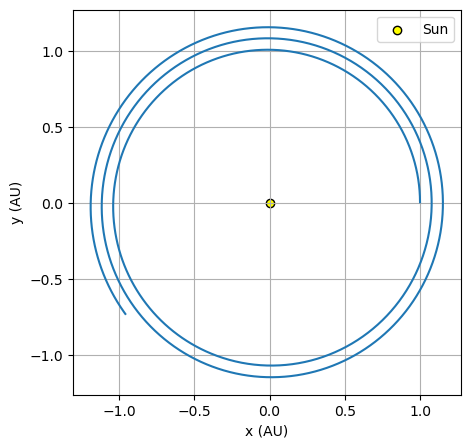

In [64]:
#testing Euler
#Orbital mech eqns - but need to do in x and y/maybe with theta (2d problem to 1d problem). Using params given by hw
G = 4*np.pi**2
M = 1 #solar mass

x, y = 0,1 #AU
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,dt = Euler(1,0,0,vcirc,3,0.001)

plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.grid()
plt.legend()

In [69]:
#Leapfrog
def leapfrog(x,y,vx,vy,time,dt):

    x_vals = []
    y_vals = []
    vx_vals = []
    vy_vals = []
  
    steps = int(time/dt)
    
    for i in range(steps):
        r = np.sqrt(x**2 + y**2) #compute position first
        ax = -G*M*x/r**3
        ay = -G*M*y/r**3
        
        #first kick (half-interval)
        vx_fhalf = vx + 0.5*ax*dt
        vy_fhalf = vy + 0.5*ay*dt
    
        #drift from first kick 
        x_new = x + vx_fhalf*dt
        y_new = y + vy_fhalf*dt

        #accel from drift
        r_new = np.sqrt(x_new**2 + y_new**2)
        ax_drift = -G*M*x_new/r_new**3
        ay_drift = -G*M*y_new/r_new**3
    
        #second kick (half-interval) - this makes the full time step
        vx_shalf = vx_fhalf + 0.5*ax_drift*dt
        vy_shalf = vy_fhalf + 0.5*ay_drift*dt

        #updating params 
        x = x_new
        y = y_new
        vx = vx_shalf
        vy = vy_shalf

        x_vals.append(x)
        y_vals.append(y)
        vx_vals.append(vx)
        vy_vals.append(vy)

    return np.array(x_vals), np.array(y_vals), np.array(vx_vals), np.array(vy_vals), dt

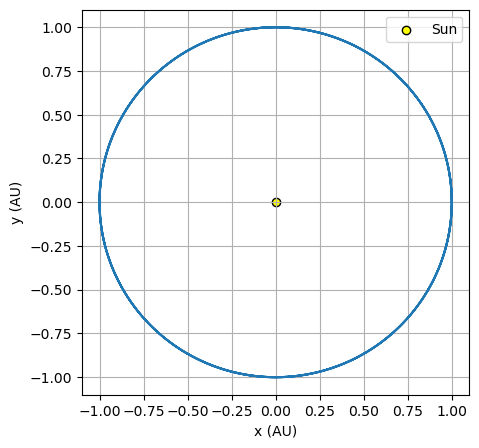

In [70]:
#testing leapfrog
#Orbital mech eqns - but need to do in x and y/maybe with theta (2d problem to 1d problem). Using params given by hw
G = 4*np.pi**2
M = 1 #solar mass

x, y = 0,1 #AU
vcirc = np.sqrt(G*M/r)

x,y,vx,vy,dt = leapfrog(1,0,0,vcirc,3,0.001)

plt.figure(figsize=(5,5))
plt.plot(x,y)
plt.scatter(0,0,color="yellow",label="Sun",alpha=1,edgecolor="black")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.grid()
plt.legend()